# Cultura Database — Getting Started

This notebook shows how to load and query the Cultura Database using DuckDB and Polars.

**Example**: Pick a polity and count the individuals active in it (using the floruit period), then plot how that count evolves over time.

In [11]:
import duckdb
import polars as pl
import matplotlib.pyplot as plt

## 1. Connect to the Database

The database is located at `data/humans_clean.duckdb`. We open it in read-only mode and pull results straight into Polars via DuckDB's native `.pl()` method.

In [12]:
DB_PATH = "data/humans_clean.duckdb"
con = duckdb.connect(DB_PATH, read_only=True)

# Quick check: how many individuals in the database?
total = con.execute("SELECT COUNT(*) AS n FROM individuals").pl()
print(f"Total individuals: {total['n'][0]:,}")

Total individuals: 13,003,420


## 2. Count Active Individuals in a Polity

The table `individuals_cliopatria` links each individual to one or more polities based on the **floruit period** (years of activit). Counting rows per polity therefore yields the number of individuals *active* in that polity.

We illustrate this on three polities from different eras: the **Roman Empire**, the **Tang Dynasty**, and the **Ottoman Empire**.

In [13]:
polities = ["Roman Empire", "Tang Dynasty", "Ottoman Empire"]

active_counts = con.execute("""
    SELECT polity_name, COUNT(*) AS active_individuals
    FROM individuals_cliopatria
    WHERE polity_name IN ?
    GROUP BY polity_name
    ORDER BY active_individuals DESC
""", [polities]).pl()

print("Active individuals per polity:")
active_counts

Active individuals per polity:


polity_name,active_individuals
str,i64
"""Tang Dynasty""",25040
"""Ottoman Empire""",12867
"""Roman Empire""",4899


In [14]:
# Pull the per-individual rows for the three polities, with their floruit year
df = con.execute("""
    SELECT polity_name, wikidata_id, name_en, floruit_year
    FROM individuals_cliopatria
    WHERE polity_name IN ?
      AND floruit_year IS NOT NULL
""", [polities]).pl()

print(f"Rows: {len(df):,}")
df.head(10)

Rows: 42,806


polity_name,wikidata_id,name_en,floruit_year
str,str,str,i32
"""Roman Empire""","""Q104713327""","""Naucellius""",332
"""Ottoman Empire""","""Q104724054""","""Apostolos Mammelis""",1918
"""Roman Empire""","""Q1047689""","""Menodotus of Nicomedia""",141
"""Ottoman Empire""","""Q104775750""","""""",1750
"""Ottoman Empire""","""Q104776901""","""Panagiotis Lazaras""",1857
"""Tang Dynasty""","""Q10478011""","""Luo Qiu""",869
"""Ottoman Empire""","""Q104781024""","""Haido Sechu""",1750
"""Ottoman Empire""","""Q104783394""","""""",1902
"""Ottoman Empire""","""Q104787915""","""Krste Jancheski""",1910


## 3. Plot Active Individuals by 50-Year Bin

For each polity, we group active individuals by 50-year bin of their `floruit_year`.

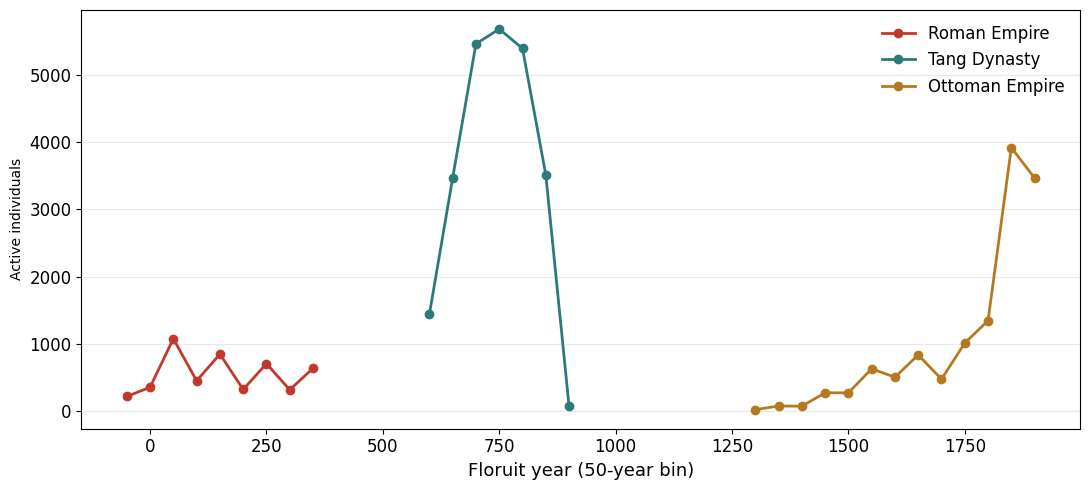

In [15]:
by_bin = (
    df
    .with_columns(((pl.col("floruit_year") // 50) * 50).alias("bin"))
    .group_by(["polity_name", "bin"])
    .agg(pl.len().alias("count"))
    .sort(["polity_name", "bin"])
)

colors = {"Roman Empire": "#c0392b", "Tang Dynasty": "#2c7a7b", "Ottoman Empire": "#b7791f"}

fig, ax = plt.subplots(figsize=(11, 5))
for polity in polities:
    sub = by_bin.filter(pl.col("polity_name") == polity).sort("bin")
    ax.plot(sub["bin"].to_list(), sub["count"].to_list(),
            marker="o", linewidth=2, color=colors[polity], label=polity)

ax.set_xlabel("Floruit year (50-year bin)", fontsize=13)
ax.set_ylabel("Active individuals")
ax.legend(fontsize=12, frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

## 4. Explore Historical Polities

Query individuals linked to historical polities via Cliopatria.

In [16]:
# Top 10 polities by number of individuals
top_polities = con.execute("""
    SELECT polity_name, COUNT(*) AS n
    FROM individuals_cliopatria
    GROUP BY polity_name
    ORDER BY n DESC
    LIMIT 10
""").pl()
print("Top 10 historical polities:")
top_polities

Top 10 historical polities:


polity_name,n
str,i64
"""United States of America""",597610
"""Kingdom of Great Britain""",277973
"""Union of Soviet Socialist Repu…",236283
"""French Fifth Republic""",201584
"""Japan""",160079
"""Federated Republic of Germany""",149974
"""Republic of Italy""",118436
"""Kingdom of Spain""",116523
"""Republic of Poland""",95651


In [17]:
# Writers in the Ottoman Empire
ottoman_writers = con.execute("""
    SELECT ic.name_en, ic.floruit_year, ic.polity_name
    FROM individuals_cliopatria ic
    JOIN individuals i ON ic.wikidata_id = i.wikidata_id
    WHERE ic.polity_name = 'Ottoman Empire'
      AND i.occupations_en LIKE '%writer%'
    ORDER BY ic.floruit_year
    LIMIT 20
""").pl()
print("Writers in the Ottoman Empire:")
ottoman_writers

Writers in the Ottoman Empire:


name_en,floruit_year,polity_name
str,i32,str
"""Gülşehri""",1339,"""Ottoman Empire"""
"""Süleyman Paşa""",1346,"""Ottoman Empire"""
"""Yahşi Fakih""",1350,"""Ottoman Empire"""
"""Molla Yegan""",1350,"""Ottoman Empire"""
"""Hayali Bey""",1350,"""Ottoman Empire"""
…,…,…
"""Hacı İlbey""",1350,"""Ottoman Empire"""
"""Abdullah Ergun""",1350,"""Ottoman Empire"""
"""Kemal Ümmi""",1350,"""Ottoman Empire"""


## 5. Explore Occupations

In [18]:
# Top 20 occupations
top_occupations = con.execute("""
    SELECT name_en, count, meta_occupation
    FROM occupations
    ORDER BY count DESC
    LIMIT 20
""").pl()
print("Top 20 occupations:")
top_occupations

Top 20 occupations:


name_en,count,meta_occupation
str,i64,str
"""researcher""",2087188,"""scientist"""
"""researcher""",2087188,"""scientist"""
"""researcher""",2087188,null
"""politician""",912043,null
"""writer""",399205,"""artist"""
…,…,…
"""historian""",120663,"""scientist"""
"""composer""",114418,"""artist"""
"""physician""",109577,null


## 6. Explore Countries of Citizenship

In [19]:
# Top 15 countries of citizenship by number of individuals
top_countries = con.execute("""
    SELECT name_en, count, iso_country_name
    FROM country_of_citizenship
    WHERE count IS NOT NULL
    ORDER BY count DESC
    LIMIT 15
""").pl()
print("Top 15 countries of citizenship:")
top_countries

Top 15 countries of citizenship:


name_en,count,iso_country_name
str,i64,str
"""United States""",659823,"""United States"""
"""France""",387185,"""France"""
"""Germany""",325196,"""Germany"""
"""Japan""",252340,"""Japan"""
"""United Kingdom""",233021,"""United Kingdom"""
…,…,…
"""Ming dynasty""",123926,"""People's Republic of China"""
"""Sweden""",115215,"""Sweden"""
"""Kingdom of the Netherlands""",106944,"""Kingdom of the Netherlands"""


In [20]:
con.close()